In [11]:
#================================Tarea 2==============================
#===================Jorge Silva Moreno===============================
import numpy as np
import matplotlib.pyplot as plt

In [12]:
#===================Ejercicio_1======================================================

#Parte (a)
#como en clase, definimos una funcion con el algoritmo del metodo de euler simple
def Euler(g,x0,t):
    h = t[1]-t[0]
    sol = np.zeros( (len(x0),len(t)) )
    sol[:,0] = x0
    for i in range(len(t)-1):
        sol[:,i+1] = sol[:,i] + h*g(sol[:,i],t[i])
    return sol


In [13]:
#Parte (b)

#Para Runge-Kuta de segundo orden solo modifique (del codigo de la parte a) los argumentos de g(x,t)

def RK2(g, x0, t):
    h=t[1]-t[0]
    sol = np.zeros( (len(x0),len(t)) )
    sol[:,0] = x0
    for i in range(len(t)-1):
        x_perp = sol[:,i] + (h/2)*g(sol[:,i],t[i])  #Esta variable la introduje para hacer mas legible el codigo
        sol[:,i+1] = sol[:,i] + h*g(x_perp,t[i]+h/2)
    return sol

In [14]:
#Parte (c)
#Como en clase, escribimos el algoritmo para Runge-Kuta de 4to orden

def RK4(g,x0,t):
    h = t[1]-t[0]
    sol = np.zeros( (len(x0),len(t)) )
    sol[:,0] = x0
    for i in range(len(t)-1):
        k1 = g(sol[:,i],t[i])
        k2 = g(sol[:,i]+0.5*k1*h,t[i]+0.5*h)
        k3 = g(sol[:,i]+0.5*k2*h,t[i]+0.5*h)
        k4 = g(sol[:,i]+k3*h,t[i]+h)
        sol[:,i+1] = sol[:,i] + h*(k1 + 2*k2 + 2*k3 + k4)/6
    return sol

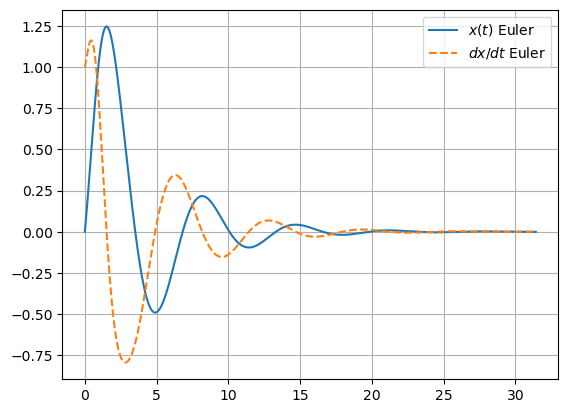

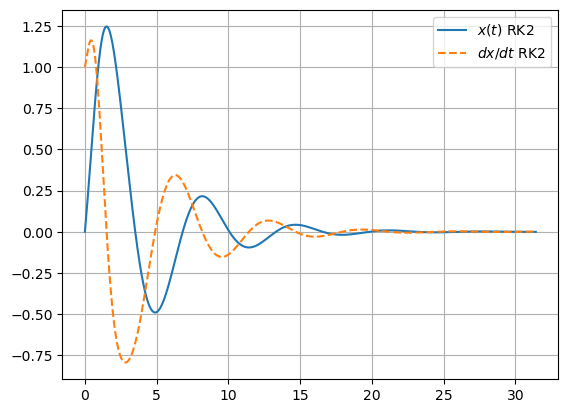

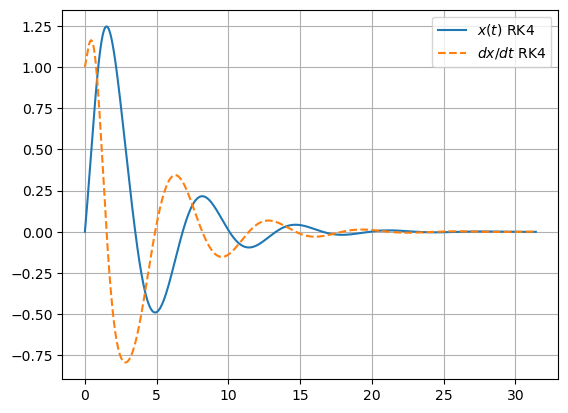

In [15]:
#Verificamos con una prueba
#Para convertir la EDO a un sistema de primer orden introducimos y=dx/dt, entonces tenemos el sistema de
#dos EDO de primer orden dado por el vector x* = (x,y) y condicion inicial x*_0=(0,1)
#Despues de un poco de algebra vemos que la EDO es equivalnete al sistema dx*/dt = g(x*,t) donnde 
#g(x*,t) esta definida como se ve a continuacion

def g(x_vec,t):
    return np.array([
        x_vec[1],
        np.exp(-t)*(np.sin(3*t)+np.cos(2*t))-0.5*x_vec[1]-np.sin(x_vec[0])
    ])


x_ini = np.array([0,1]) #Condicion inicial
t = np.arange(0,10*np.pi,0.001)
sol_euler = Euler(g,x_ini,t)
sol_RK2= RK2(g,x_ini,t)
sol_RK4= RK4(g,x_ini,t)

#Grafica de Euler
plt.plot(t,sol_euler[0,:],label=r'$x(t)$ Euler')
plt.plot(t,sol_euler[1,:],'--',label=r'$dx/dt$ Euler')
plt.grid(),plt.legend()
plt.show()

plt.figure()
#Grafica de RK2
plt.plot(t,sol_RK2[0,:],label=r'$x(t)$ RK2')
plt.plot(t,sol_RK2[1,:],'--',label=r'$dx/dt$ RK2')
plt.grid(),plt.legend()
plt.show()

plt.figure()
#Grafica de RK4
plt.plot(t,sol_RK4[0,:],label=r'$x(t)$ RK4')
plt.plot(t,sol_RK4[1,:],'--',label=r'$dx/dt$ RK4')
plt.grid(),plt.legend()
plt.show()

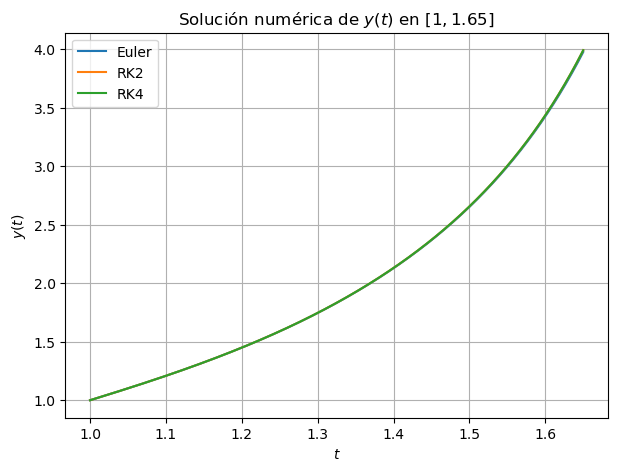

In [16]:
#=========================Ejercicio_2========================

#Utilizando una tecnica similar al ejercicio anterior, definimos el vector x*=(a,b,c)=(y,D(y), D^2(y)) 
#donde D es el operador deivada temporal y condicion inicial x*=(1,2,1).
#Entonces de la EDO de 3ter orden obtenemos el sistema de 3x3
# dx*/dt = g(x*,t), donde g (despues de un poco de algebra) viene dada por

def G(x_vec,t):
    return np.array([
        x_vec[1], x_vec[2],
        np.exp(-t)*np.sin(3*t)-x_vec[2]**2+3*x_vec[1]**3-np.cos(x_vec[0])**2
    ])

x_ini_2 = np.array([1.0, 2.0, 1.0]) #Condicion inicial

t0 = 1.0
tf = 1.65

N = 800
T = np.linspace(t0, tf, N + 1)

sol_euler = Euler(G, x_ini_2, T)
sol_RK2   = RK2(G, x_ini_2, T)
sol_RK4   = RK4(G, x_ini_2, T)

#Grafica de la solucion numerica

plt.figure(figsize=(7, 5))

plt.plot(T, sol_euler[0, :], label='Euler')
plt.plot(T, sol_RK2[0, :], label='RK2')
plt.plot(T, sol_RK4[0, :], label='RK4')

plt.xlabel(r'$t$')
plt.ylabel(r'$y(t)$')
plt.title(r'Solución numérica de $y(t)$ en $[1,1.65]$')
plt.grid()
plt.legend()
plt.show()


In [19]:
#Aqui calculamos el error

"""
Como la ecuación no tiene una solución analítica conocida,
para cada método se comparó la solución obtenida con paso h con la solución obtenida con paso h/2. 
Como Euler simple, RK2 y RK4 son métodos de orden 1,2 y 4, respectivamente, el error de la solución refinada se estimó como

    E_h/2 approx (|y_{h/2}-y_h|)/(2^p-1) con p el orden del metodo

El sistema se resolvio como un sistema x*=(a,b,c)=(y,D(y), D^2(y))
entonces tenemos que calcular el paso de 4 cifras significativas para el vector x*

Se exigió que el error relativo máximo fuera menor que 5e-5,lo cual garantiza aproximadamente cuatro cifras significativas
"""

def error_paso_vector(metodo, orden, G, x_ini, t0, tf, N):
    T_h = np.linspace(t0, tf, N + 1)
    T_h2 = np.linspace(t0, tf, 2*N + 1)

    sol_h = metodo(G, x_ini, T_h)
    sol_h2 = metodo(G, x_ini, T_h2)

    sol_h2_en_h = sol_h2[:, ::2]

    diferencia = np.abs(sol_h2_en_h - sol_h)

    escala = np.maximum(np.abs(sol_h2_en_h), 1e-14)

    error_relativo = np.max(diferencia / escala)

    error_estimado = error_relativo / (2**orden - 1)

    h_fino = (tf - t0)/(2*N)

    return error_estimado, h_fino


def buscar_paso_vector(metodo, orden, G, x_ini, t0, tf, tol=5e-5):
    N = 50

    while True:
        error, h = error_paso_vector(metodo, orden, G, x_ini, t0, tf, N)

        if error < tol:
            return h, 2*N, error

        N *= 2


x_ini_2 = np.array([1.0, 2.0, 1.0])

t0 = 1.0
tf = 1.65

tol = 5e-5

h_euler, N_euler, err_euler = buscar_paso_vector(Euler, 1, G, x_ini_2, t0, tf, tol)
h_RK2, N_RK2, err_RK2 = buscar_paso_vector(RK2, 2, G, x_ini_2, t0, tf, tol)
h_RK4, N_RK4, err_RK4 = buscar_paso_vector(RK4, 4, G, x_ini_2, t0, tf, tol)

print("\n Euler")
print("h =", h_euler)
print("N =", N_euler)
print("error estimado =", err_euler)

print("\n RK2")
print("h =", h_RK2)
print("N =", N_RK2)
print("error estimado =", err_RK2)

print("\n RK4")
print("h =", h_RK4)
print("N =", N_RK4)
print("error estimado =", err_RK4)


 Euler
h = 1.5869140624999997e-06
N = 409600
error estimado = 2.614574442370409e-05

 RK2
h = 0.0008124999999999999
N = 800
error estimado = 1.8861579826916252e-05

 RK4
h = 0.006499999999999999
N = 100
error estimado = 2.398724712203312e-05


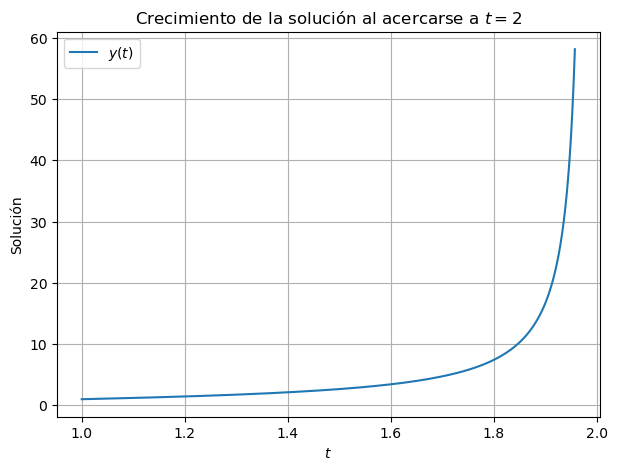

In [20]:
#Limite t=2

T_largo = np.linspace(1.0, 1.9571, 95001)

sol_largo = RK4(G, x_ini_2, T_largo)

plt.figure(figsize=(7, 5))
plt.plot(T_largo, sol_largo[0, :], label=r'$y(t)$')
plt.xlabel(r'$t$')
plt.ylabel('Solución')
plt.title(r'Crecimiento de la solución al acercarse a $t=2$')
plt.grid()
plt.legend()
plt.show()

#De la grafica podemos observar que la solucion crece hacia +infinito conforme nos acercamos a 2
#Inclusive, co se puede notar en T_largo, intente graficar lo mas cercano a 2
#Pero para un limite superior mayor a 1.9571 python alertaba que el valor de y(t) calculado era extremadamente grande

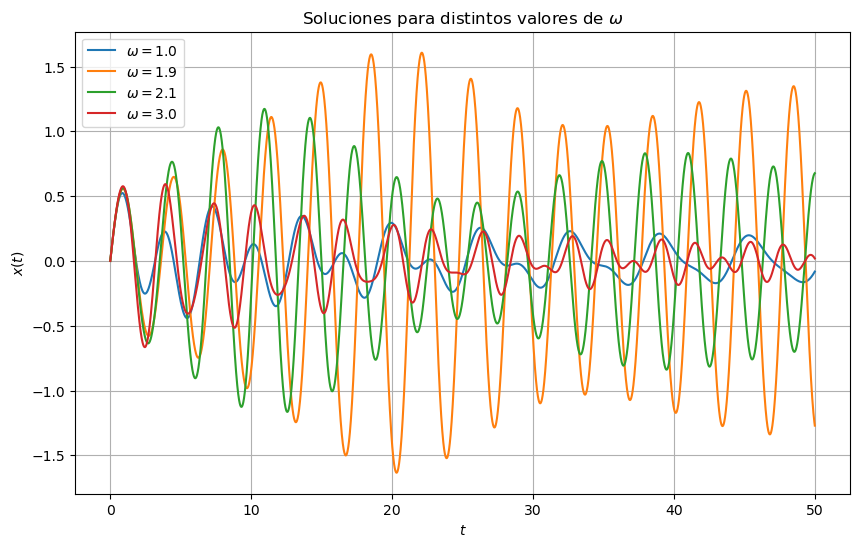

In [21]:
#===================Ejercico_3============================

#Basta con agregar la opcion de parametros adicionales a nuestras funciones que ya teniamos en el Ej 1

def Euler_opt(g, x0, t, *args):
    h = t[1] - t[0]
    sol = np.zeros((len(x0), len(t)))
    sol[:, 0] = x0

    for i in range(len(t)-1):
        sol[:, i+1] = sol[:, i] + h*g(sol[:, i], t[i], *args)

    return sol

def RK2_opt(g, x0, t, *args):
    h = t[1] - t[0]
    sol = np.zeros((len(x0), len(t)))
    sol[:, 0] = x0

    for i in range(len(t)-1):
        x_perp = sol[:, i] + (h/2)*g(sol[:, i], t[i], *args)
        sol[:, i+1] = sol[:, i] + h*g(x_perp, t[i] + h/2, *args)

    return sol

def RK4_opt(g, x0, t, *args):
    h = t[1] - t[0]
    sol = np.zeros((len(x0), len(t)))
    sol[:, 0] = x0

    for i in range(len(t)-1):
        k1 = g(sol[:, i], t[i], *args)
        k2 = g(sol[:, i] + 0.5*h*k1, t[i] + 0.5*h, *args)
        k3 = g(sol[:, i] + 0.5*h*k2, t[i] + 0.5*h, *args)
        k4 = g(sol[:, i] + h*k3, t[i] + h, *args)

        sol[:, i+1] = sol[:, i] + h*(k1 + 2*k2 + 2*k3 + k4)/6

    return sol

#Nuevamente hacemos la sustitucion x*=(x,y)=(x, D(x)) y reducimos el sistema de 2do orden un sistema 2x2 de 1er orden
#de la fomr adx*/dt=g(x*,t) donde g esta dada de la forma

def g3(x_vec, t, omega):
    return np.array([
        x_vec[1],
        0.5*np.sin(omega*t) - 0.1*x_vec[1] - 4*np.sin(x_vec[0])
    ])

#Soluciones para varios omega

x_0 = np.array([0, 1])

t_om = np.arange(0, 50, 0.01)

omegas = np.round(np.arange(1.0, 3.0 + 0.1, 0.1), 1)

sol_euler, sol_RK2, sol_RK4 = {}, {}, {}

for omega in omegas:
    sol_euler[omega] = Euler_opt(g3, x_0, t_om, omega)
    sol_RK2[omega] = RK2_opt(g3, x_0, t_om, omega)
    sol_RK4[omega] = RK4_opt(g3, x_0, t_om, omega)

#Graficamos algunas soluciones, podemos graficar con cualquier metodo pero aqui eleji usar RK4

omegas_graficar = [1.0, 1.9, 2.1, 3.0]

plt.figure(figsize=(10, 6))

for omega in omegas_graficar:
    plt.plot(t_om, sol_RK4[omega][0, :], label=rf'$\omega = {omega}$')

plt.xlabel(r'$t$')
plt.ylabel(r'$x(t)$')
plt.title(r'Soluciones para distintos valores de $\omega$')
plt.grid()
plt.legend()
plt.show()

In [ ]:
"""
Notamos  que para tiempos largos, la amplitud de la solucion es mayor para valores cercanos a 2 de omega
mientras que para valores de omega alejados de 2, la amplitud es mucho menor.

Esto se explica porque podemos reconocer a la EDO (de forma aproximada) como un oscilador forzado amortiguado, 
de la teoria ya conocida de este problema:
identificamos a omega como la frecuencia de forzamiento, mientras que la frecucnia de vibracion natural es 2. Entonces

    -Para valores de la frecuncia de forzamiento (omega) cercanos a 2 (frecuencia natural), se produce resonancia 
    y el oscilador se ve dominado por el forzamiento con poco amortiguamienti
    -Para valores de omega alejados de 2, el amortiguamiento domina, de modo que para tiempos largos, el oscilador va perdiento 
    energia mas energia (a comparacion de cuando hay resonancia).
"""

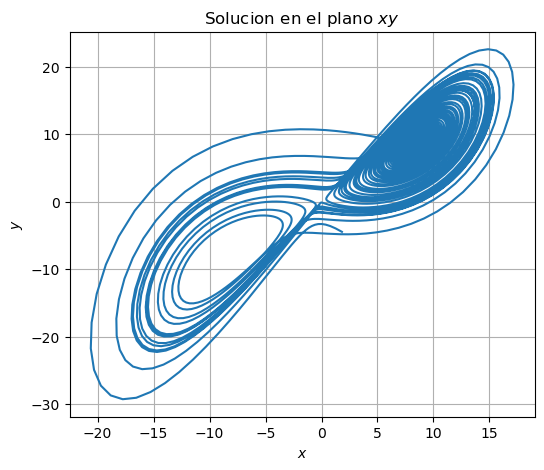

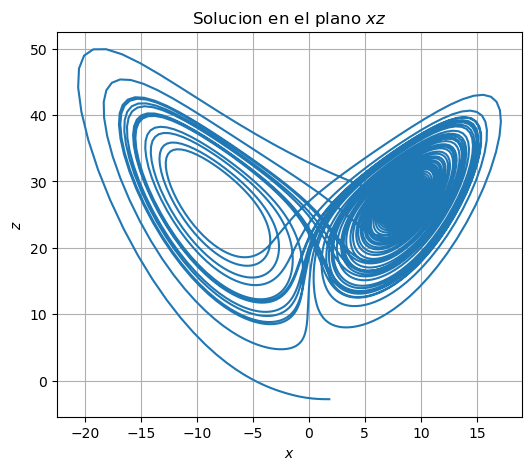

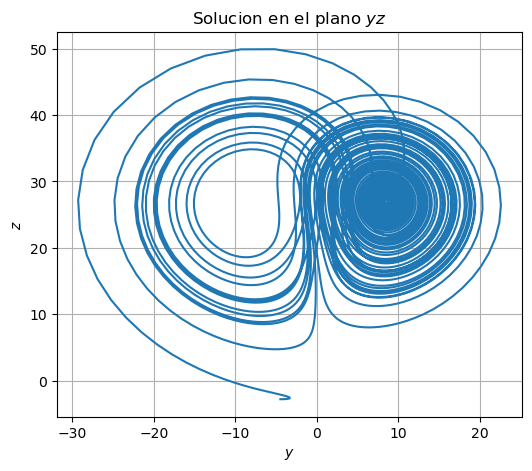

In [22]:
#====================EJercicio 4====================================

#Como hemos venido haciendo, introducimos el vector r=(x,y,z)
#de modo que podemos reescribir el sistema como dr/dt=L(r,t), donde L esta dada como sigue

def L(r, t):
    x = r[0]
    y = r[1]
    z = r[2]
    return np.array([
        10*(y - x),
        x*(28 - z) - y,
        x*y - (8/3)*z
    ])

#Parte (a)

#Condicion inicial

rng = np.random.default_rng(123)

r_ini = rng.uniform(-5, 5, 3)


#Graficas

t_ex = np.arange(0, 60, 0.01) #aqui fui probando manualmente el paso h, lo deje con h=0.01

soluciones = RK4(L, r_ini, t_ex) #El metodo que eleji fue RK4

x = soluciones[0, :]
y = soluciones[1, :]
z = soluciones[2, :]

#Plano XY

plt.figure(figsize=(6, 5))
plt.plot(x, y)
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title(r'Solucion en el plano $xy$')
plt.grid()
plt.show()

#Plano XZ

plt.figure(figsize=(6, 5))
plt.plot(x, z)
plt.xlabel(r'$x$')
plt.ylabel(r'$z$')
plt.title(r'Solucion en el plano $xz$')
plt.grid()
plt.show()

#PLano YZ
plt.figure(figsize=(6, 5))
plt.plot(y, z)
plt.xlabel(r'$y$')
plt.ylabel(r'$z$')
plt.title(r'Solucion en el plano $yz$')
plt.grid()
plt.show()

In [ ]:
"""
Vemos que para cada plano, las soluciones se mantiene acotadas a una region de dicho plano, 
lo que implica que la solucion (x,y,z) se mantiene acotada en una regio del espacio. 
"""

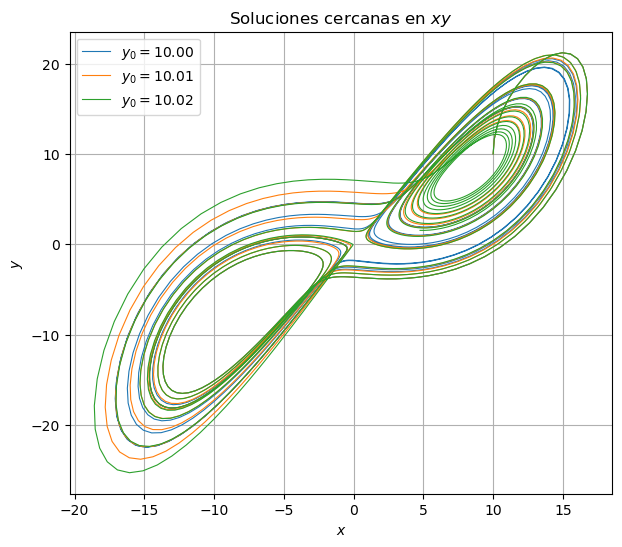

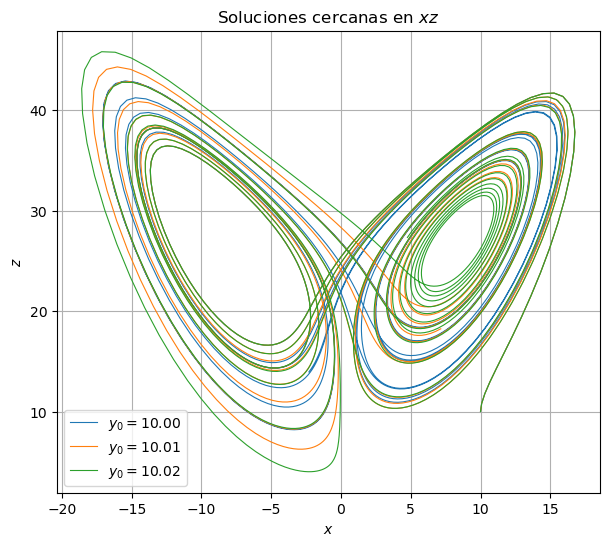

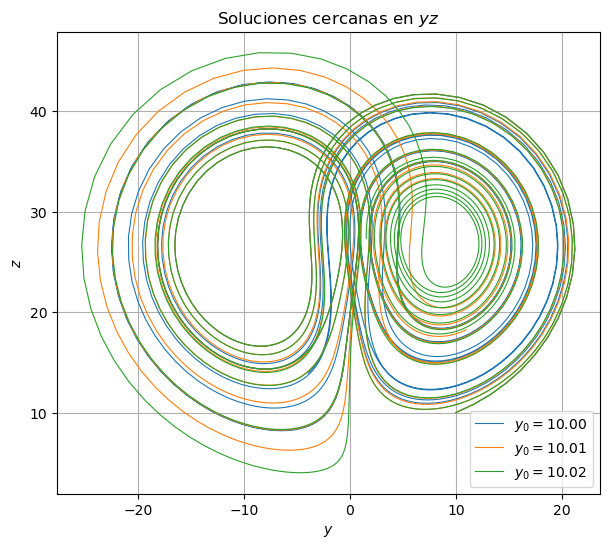

In [23]:
#Parte (b)

#Condiciones inciales elejidas
#Como se requiere, la diferencia entre coordendas en y difieren por por 0.01
r1_ini = np.array([10.0, 10.00, 10.0])
r2_ini = np.array([10.0, 10.01, 10.0])
r3_ini = np.array([10.0, 10.02, 10.0])

"""
Como vimos en la parte (a), las soluciones se mantiene acotadas, aqui probe varios valores del rango para t_lenz,
y termine elijiendo un tiempo un poco corto que hace que se vea mas claro como las soluciones
empiezan siendo muy parecidas (mas adelante se ve que el punto (10,10,10) desde donde empiezan las soluciones 
es facilmente identificable de las graficas) y despues empiezan a separarse notoriamente.
"""

t_lenz = np.arange(0, 15, 0.01) 
sol1 = RK4(L, r1_ini, t_lenz)
sol2 = RK4(L, r2_ini, t_lenz)
sol3 = RK4(L, r3_ini, t_lenz)

#Graficas en XY

plt.figure(figsize=(7, 6))

plt.plot(sol1[0, :], sol1[1, :], label=r'$y_0 = 10.00$', linewidth=0.8)
plt.plot(sol2[0, :], sol2[1, :], label=r'$y_0 = 10.01$', linewidth=0.8)
plt.plot(sol3[0, :], sol3[1, :], label=r'$y_0 = 10.02$', linewidth=0.8)

plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title(r'Soluciones cercanas en $xy$')
plt.grid()
plt.legend()
plt.show()

#Graficas en XZ

plt.figure(figsize=(7, 6))

plt.plot(sol1[0, :], sol1[2, :], label=r'$y_0 = 10.00$', linewidth=0.8)
plt.plot(sol2[0, :], sol2[2, :], label=r'$y_0 = 10.01$', linewidth=0.8)
plt.plot(sol3[0, :], sol3[2, :], label=r'$y_0 = 10.02$', linewidth=0.8)

plt.xlabel(r'$x$')
plt.ylabel(r'$z$')
plt.title(r'Soluciones cercanas en $xz$')
plt.grid()
plt.legend()
plt.show()

#Graficas en yz

plt.figure(figsize=(7, 6))

plt.plot(sol1[1, :], sol1[2, :], label=r'$y_0 = 10.00$', linewidth=0.8)
plt.plot(sol2[1, :], sol2[2, :], label=r'$y_0 = 10.01$', linewidth=0.8)
plt.plot(sol3[1, :], sol3[2, :], label=r'$y_0 = 10.02$', linewidth=0.8)

plt.xlabel(r'$y$')
plt.ylabel(r'$z$')
plt.title(r'Soluciones cercanas en $yz$')
plt.grid()
plt.legend()
plt.show()

In [ ]:
"""
De las graficas podemos observar que las trayectorias para cada solucion inicialmente son muy parecidas. 
Sin embargo, después de cierto tiempo comienzan a separarse de manera notable.

Esto indica que nuestro sistema de EDs es sensible a las condiciones iniciales: diferencias pequeñas
en las condiciones iniciales producen trayectorias notablemente distintas para tiempos largos.
"""